# UCL HACKATHON 2025

## Packages and framework
First ensure that you have the correct python packages installed. All required imports are included in the requirements.txt file. To install all of these use the code 'pip install requirements.txt'.

The classes that will handle the simulated trade execution are imported from 'ResearchClass' DO NOT CHANGE the file in anyway or your code is very unlikely to run.

## Example
Included is an example usage of the provided classes. For more information please consult the members of MCD present at the venue.

There are two functions that you will need to change, the first is the $\bold{'AddIndicator'}$ Method which overloads the empty one in 'StrategyTemplate'. This will add the values of the indicators you have used to the dataframe used to calculate your trades. Remeber that if you choose to use an indicator with a warm up period do not be suprised to see 'nan' data types. The method $\bold{'strategyLogic'}$ will not be called until the full row is void of nans.

The second method, $\bold{'strategyLogic'}$ is where the magic happens. This will be called by the trader to decide when a trade is taken and how open positions are managed. You have the ability to open trades with predefined take profit and stop loss levels as well as access the current position and force close a position.


## Evaluation

You will be evaluated on all of the metrics of your strategy as well as the quailty of your logic and the way that you apply state of the art research.


## Presentation

If you are using more complex mathematical or computational ideas we expect the notebook to contain descriptions of the objects, forulas, etc that are used, as well as references for novel techniques. We will be assess your ability to impliment mathematical ideas on the fly and apply novel techniques. A portion of the marking will be $\bold{qualitative}$ so make sure we understand the logic you are using. Otherwise we will be forced to assume you found a good ChatGPT prompt.

Note that for common ideas we will accept a simple statement such as 'indicator name, link to investodpidia' etc. If you choose to use a NN please explain the atchitecure and ensure that you describe how you design, train, and update you model.

## Advice

You are encouraged to consider extra data where approptiate, this can be taken from wherever you like, but be sure to check that the dates are properly aligned.
Also feel free to subset the data for testing ideas quickly, on some hardware these dataset can take a while to process. This can be done in pandas but ensure that we can take your notebook and data and simply hit 'run all'. Should this result in an error you will score 0.


## Metrics and Definitions

### 1. Sharpe Ratio
The Sharpe ratio measures the average return earned in excess of the risk-free rate per unit of volatility or total risk. A negative Sharpe ratio implies that the strategy performed worse than a risk-free asset.

$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$

Where:
- $R_p $: Average portfolio return  
- $R_f $: Risk-free rate  
- $\sigma_p $: Standard deviation of portfolio returns  

---

### 2. Sortino Ratio
The Sortino ratio is a variation of the Sharpe ratio that focuses only on downside risk, using the standard deviation of negative returns.

$
\text{Sortino Ratio} = \frac{R_p - R_f}{\sigma_d}
$

Where:
- $R_p $: Average portfolio return  
- $R_f $: Risk-free rate  
- $\sigma_d $: Standard deviation of downside returns  

---

### 3. t-statistic
The t-statistic is used to evaluate whether the average return of the strategy is statistically significantly different from zero.

$
t\text{-stat} = \frac{\bar{R}}{\frac{\sigma}{\sqrt{n}}}
$

Where:
- $\bar{R} $: Mean return  
- $\sigma $: Standard deviation of returns  
- $n $: Number of trades or data points  

---

### 4. Total Return
Total return represents the percentage increase or decrease in the portfolio value over the evaluation period.

$
\text{Total Return} = \frac{\text{Ending Value} - \text{Starting Value}}{\text{Starting Value}} \times 100
$

---

### 5. Win Rate
Win rate is the percentage of profitable trades out of the total number of trades executed.


\text{Win Rate} = \frac{\text{Number of Winning Trades}}{\text{Total Number of Trades}} \times 100


---

### 6. Average Trade Return
The average return per trade, considering all trades executed (both profitable and losing trades).

$
\text{Average Trade} = \frac{\text{Total Profit or Loss}}{\text{Number of Trades}}
$

---

### 7. Average Win Return
The average return of only the profitable trades.

$
\text{Average Win} = \frac{\text{Total Profit from Winning Trades}}{\text{Number of Winning Trades}}
$

---

### 8. Average Loss Return
The average return of only the losing trades.

$
\text{Average Loss} = \frac{\text{Total Loss from Losing Trades}}{\text{Number of Losing Trades}}
$

---

### 9. Minimum Trade Size
The smallest trade size (negative in this case) recorded over the evaluation period.

---

### 10. Average Trade Time
The average duration of all trades, typically measured in time units (e.g., seconds, minutes).

$
\text{Average Trade Time} = \frac{\sum \text{(Time Duration of All Trades)}}{\text{Total Number of Trades}}
$

---

### 11. Average Win Time
The average duration of winning trades.

$
\text{Average Win Time} = \frac{\sum \text{(Time Duration of Winning Trades)}}{\text{Number of Winning Trades}}
$

---

### 12. Average Loss Time
The average duration of losing trades.

$
\text{Average Loss Time} = \frac{\sum \text{(Time Duration of Losing Trades)}}{\text{Number of Losing Trades}}
$


In [27]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import Figure as fig
from pylab import rcParams
import datetime
from datetime import timedelta
import statsmodels.api as sm
rcParams['figure.figsize'] = 20,10
from ResearchClass import PlotEvaluations, EvaluationMetrics, TradesBook, StrategyTemplate
import os

pd.options.mode.chained_assignment = None  # default='warn'


        Assets:		 ['data/MNQc1.parquet']
        Start date:	 2024-11-27 00:00:00
        End date:	 2025-01-25 00:00:00
        Frequency: 	 2m
        ---------------------------
        trade_df:		 1711
        Costs: 		 $5475.200000000001/month
        Sharpe:		 -0.463 
        Sortino:	 -0.205 
        t-stat:		 -2.471
        Total return: 	 81.821%
        Win rate:	 86.67%
        Avg trade:	 -0.012%
        Avg win:	 0.028% 
        Avg loss:	 -0.266%
        Min trade size:	 $-47453281
        Avg trade time:	 1332.822910578609
        Avg win time:	 1145.2157788267027
        Avg loss time:	 2553.092105263158
        


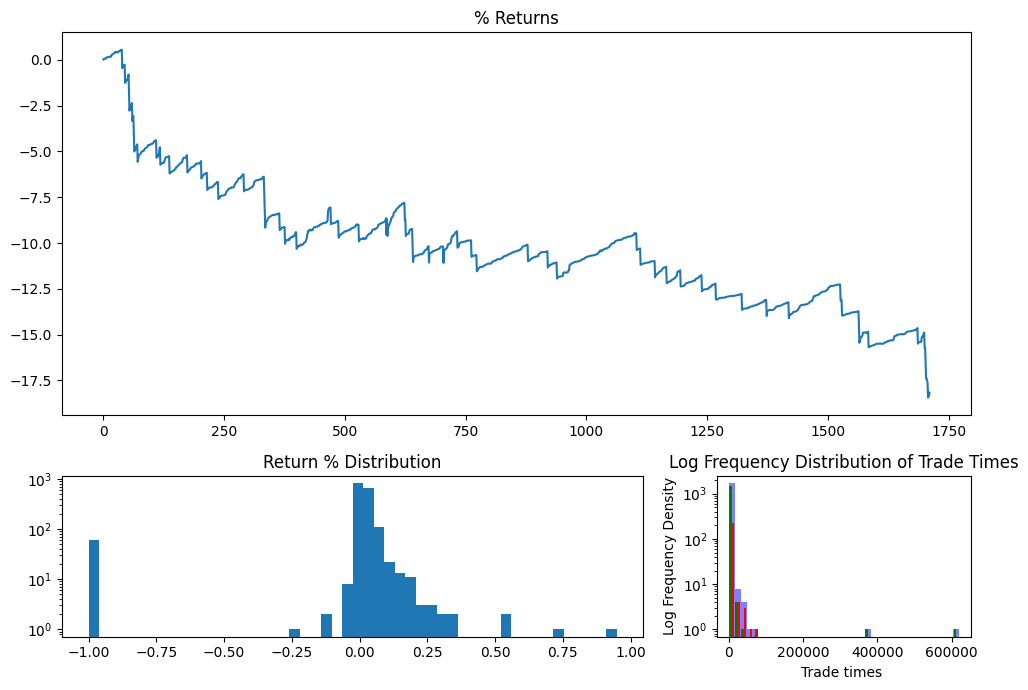

In [28]:
class BollingerBandsIndicator(StrategyTemplate):
    """
    Bollinger Bands strategy class that inherits from StrategyTemplate.
    This strategy generates buy and sell signals based on Bollinger Bands.
    """
    def __init__(self, data, start_date, end_date, interval, indicator_parameters):
        self.data=data
        self.indicator_parameters=indicator_parameters

    def AddIndicators(self):
        """
        Adds Bollinger Bands indicators to the data.
        Bollinger Bands consist of a middle SMA band, upper band, and lower band.
        """
        LOOKBACK_PERIOD = self.indicator_parameters[0]  # Bollinger Bands lookback period
        STD_DEV_MULTIPLIER = self.indicator_parameters[1]  # Standard deviation multiplier


        # Calculate Bollinger Bands
        self.data['BB_MIDDLE'] = self.data['Close'].rolling(LOOKBACK_PERIOD).mean()
        self.data['BB_STD'] = self.data['Close'].rolling(LOOKBACK_PERIOD).std()
        self.data['BB_UPPER'] = self.data['BB_MIDDLE'] + (STD_DEV_MULTIPLIER * self.data['BB_STD'])
        self.data['BB_LOWER'] = self.data['BB_MIDDLE'] - (STD_DEV_MULTIPLIER * self.data['BB_STD'])

    def strategyLogic(self, TradeBook, row, idx):
        """
        Defines the Bollinger Bands strategy logic.

        Parameters:
        - TradeBook: The TradeBook object that manages trades.
        - row: The current row of data.
        - idx: The current index in the data.
        """
        # Skip the initial periods to allow for indicator warmup
        if idx < self.indicator_parameters[0]:
            return

        # Close trade if an active order execution price is met
        if TradeBook.CurrentSizing() != 0 and TradeBook.ActiveOrderExecutionPrice(row):
            TradeBook.CloseTrade(TradeBook.ActiveOrderExecutionPrice(row), idx)

        # Open a long trade if price crosses above the lower Bollinger Band
        if TradeBook.CurrentSizing() == 0 and row['Close'] < row['BB_LOWER']:
            entry = row['Open']
            stop = row['Open'] * (1 - self.indicator_parameters[2])  # Stop-loss as a percentage of entry
            target = row['BB_MIDDLE']  # Target set to middle band
            TradeBook.OpenTrade(entry, 1, stop, idx, target)

        # Open a short trade if price crosses below the upper Bollinger Band
        if TradeBook.CurrentSizing() == 0 and row['Close'] > row['BB_UPPER']:
            entry = row['Open']
            stop = row['Open'] * (1 + self.indicator_parameters[2])  # Stop-loss as a percentage of entry
            target = row['BB_MIDDLE']  # Target set to middle band
            TradeBook.OpenTrade(entry, -1, stop, idx, target)
# Parameters: [lookback period, std deviation multiplier, stop loss percentage]
parameters = [25, 1, 0.010] #Stop loss percentage optimised after trial and error
#Standard deviation optimised
ticker_list = ['data/MNQc1.parquet']
today = datetime.datetime.now()
start_date = str((today - datetime.timedelta(days=59)).strftime("%Y-%m-%d"))
end_date = str(today.strftime("%Y-%m-%d"))
interval = "1m" #to better capture highs and lows

# Apply the Bollinger Bands strategy
#BB_TRADE_BOOK = BollingerBandsIndicator(ticker_list, start_date, end_date, interval, parameters).ApplyStrategyThroughTickers()

# Evaluate the strategy performance
#bb_metrics = EvaluationMetrics(BB_TRADE_BOOK, ticker_list, start_date, end_date)
#bb_plots = PlotEvaluations(BB_TRADE_BOOK, (10, 7))

# Print the evaluation metrics and plot the summary
#bb_metrics.print_results()
#bb_plots.PlotSummary()


